# what distortion results from projecting episode into alternate spaces?

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

### paths to data dirs

In [2]:
annot_dir = '../../data/annotations_dfs/'
model_dir = '../../data/models/'
transc_dir = '../../data/transcriptions/automatic/'
pickle_dir = '../../data/pickles/'

## load annotations dataframes

In [3]:
atlep1_df = pd.read_pickle(annot_dir+'atlep1.p')
atlep2_df = pd.read_pickle(annot_dir+'atlep2.p')
arrdev_df = pd.read_pickle(annot_dir+'arrdev.p')

## model parameters

In [4]:
n_topics = 100
episode_wsize = 50
recall_wsize = 200

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

## functions for topic modeling and interpolation

In [5]:
def format_episode_text(textlist):
    """
    takes care of standardizing annotation text format for modeling
    """
    new_textlist = []
    
    for chunk in textlist:
        
        new_chunks = []
        for subchunk in chunk.split(','):
            # remove all characters except letters, spaces, apostrophes, dashes. Put all in uppercase
            upper_nopunc = re.sub("[^\w\s'-]+", '', subchunk.upper())

            # remove accented characters
            no_acc = upper_nopunc.replace('É', 'E')

            # convert digits to numbers
            if any(word.isdigit() for word in no_acc.split(' ')):
                for word in no_acc.split(' '):
                    if word.isdigit():
                        no_acc = no_acc.replace(word, num2words(int(word)).upper())
                    
            new_chunks.append(no_acc)
        
        new_textlist.append(','.join(new_chunks))
    
    return new_textlist

In [6]:
def get_episode_windows(episode_df, episode_wsize=episode_wsize):
    # throw all annotations into bag of words to train model
    episode_bag = format_episode_text(episode_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())

    # create list for annotation sliding windows (of size w_size)
    episode_w = []
    for idx, sentence in enumerate(episode_bag):
        episode_w.append(','.join(episode_bag[idx:idx+episode_wsize]))

    return episode_w

In [7]:
def find_midpoint_time(df, endframe_time):
    """
    returns list of timepoints at middle of each annotation segment
    """
    midpoint_times = []
    for i, tpt in enumerate(df['Onset time']):
        if i != len(df['Onset time'])-1:
            midpoint_time = np.mean([tpt, df['Onset time'][i+1]])
        else:
            midpoint_time = np.mean([tpt, endframe_time])
        midpoint_times.append(midpoint_time)

    return midpoint_times

In [8]:
def interpolate_model(model, df, endframe_time, resolution=1):

    """
    uses linear interpolation to resample episode model timeseries to desired resolution. 
    'resolution' is in units of seconds (default is 1s).
    """
    
    # get middle timepoint for each annotation
    midpoint_times = find_midpoint_time(df, endframe_time)
    
    new_model = np.empty((int(round(endframe_time)),np.shape(model)[1]))
    
    # loop over topic dimensions
    for dim in range(np.shape(model)[1]):
        # values for given dimension at each timepoint
        single_dim = []
        for tpt in range(np.shape(model)[0]):
            single_dim.append(model[tpt][dim])
        
        # create interpolation function from dimension timeseries
        interp_func = interpolate(midpoint_times, single_dim, fill_value='extrapolate')
        
        # set of new timepoints
        new_tpts = np.arange(int(round(endframe_time)), step=resolution)
        
        # interpolate single topic dimension trajectory new timescale
        single_dim_res = interp_func(new_tpts)
        
        # fill in array for resampled model
        for ix, new_tpt in enumerate(single_dim_res):
            new_model[ix][dim] = new_tpt
    
    return new_model

In [9]:
def model_and_transform(documents, resample_shape=None, n_topics=n_topics, vec_params=vectorizer_params, 
                        sem_params=semantic_params, corpus=None):
    
    # if an episode dataframe is passed, create overlapping text windows from annotations
    if type(documents) is pd.core.frame.DataFrame:
        wsize = episode_wsize
        windows = get_episode_windows(documents, wsize)
    
        # if no corpus is passed, project episode into self-defined representational space
        if corpus == None:
            corpus = windows
        
    # if a transcript is passed, create overlapping windows from speech segments
    elif type(documents) is str:
        wsize = recall_wsize
        windows = get_recall_windows(documents, wsize)
            
    # use hypertools to create episode model
    model =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
    
    # resample episode model using interpolation and corresponding endframe time
    if type(documents) is pd.core.frame.DataFrame:
        
        if np.shape(documents) == np.shape(atlep1_df):
            endframe_time = 1466.0
        elif np.shape(documents) == np.shape(atlep2_df):
            endframe_time = 1316.52
        elif np.shape(documents) == np.shape(arrdev_df):
            endframe_time = 1236.6
            
        return interpolate_model(model, documents, endframe_time)
    
    # resample recall model to shape of corresponding episode model
    elif type(documents) is str:
        return resample(model, resample_shape)

## create corpus for each topic space

In [10]:
atlep1_corpus = get_episode_windows(atlep1_df)

atlep2_corpus = get_episode_windows(atlep2_df)

arrdev_corpus = get_episode_windows(arrdev_df)

all_eps_corpus = atlep1_corpus + atlep2_corpus + arrdev_corpus

wiki_docs = hyp.load('wiki').get_data()
wiki_corpus = []
for article in range(np.shape(wiki_docs)[1]):
    wiki_corpus.append(wiki_docs[0][article][0].decode('utf8').replace('\n',' '))

## array of content trajectories in topic spaces

In [11]:
# ep_inspace = pd.DataFrame(columns=['atlep1','atlep2','arrdev'], index=['atlep1','atlep2','arrdev','all','wikipedia'])

# for col, content in enumerate([atlep1_df, atlep2_df, arrdev_df]):
#     for row, corpus in enumerate([atlep1_corpus, atlep2_corpus, arrdev_corpus, all_eps_corpus, wiki_corpus]):
#         ep_inspace.iat[row,col] = model_and_transform(content, corpus=corpus)


In [12]:
# with open(pickle_dir+'/ep_inspace.p', 'wb') as f:
#     pickle.dump(ep_inspace, f)

In [13]:
with open(pickle_dir+'/ep_inspace.p', 'rb') as f:
    ep_inspace = pickle.load(f)

## plot each episode trajectory in each topic space

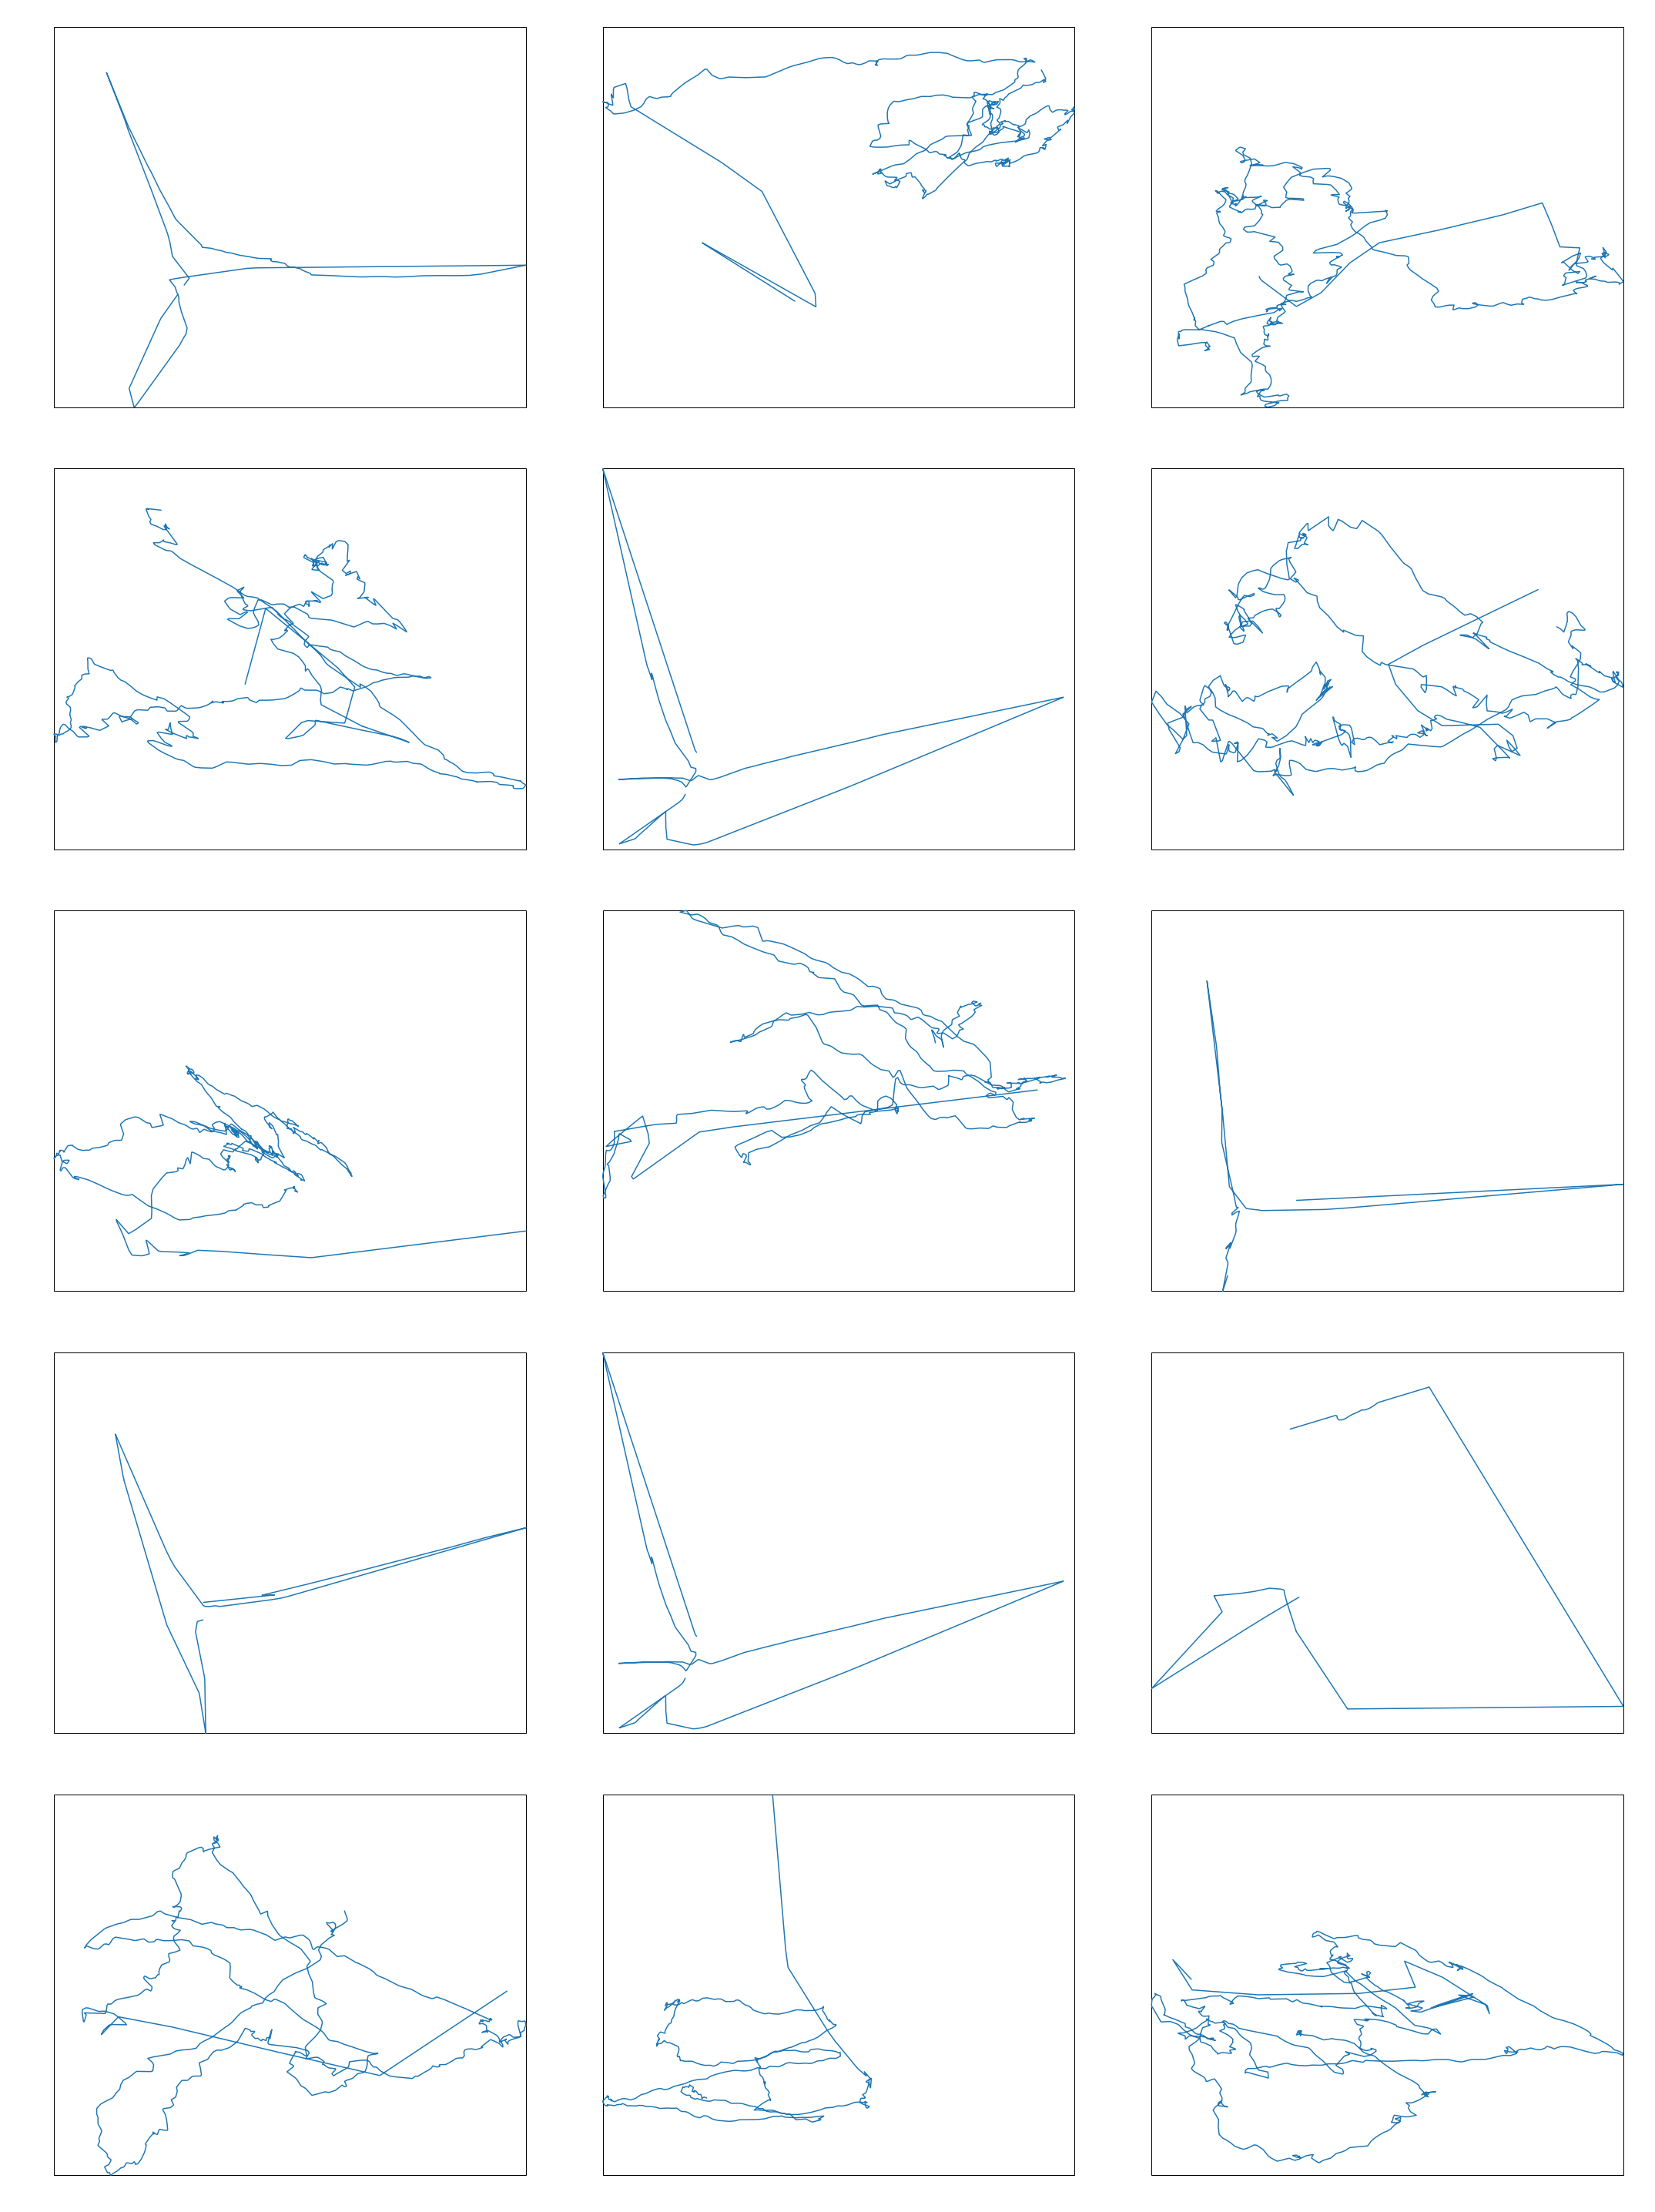

In [14]:
# working 2d plots
fig, ax = plt.subplots(5,3)
fig.set_size_inches(30,40)

for (i,j), axis in np.ndenumerate(ax):
    hyp.plot(ep_inspace.iloc[i,j], ndims=2, ax=axis, show=False)
    
fig

In [15]:
# fig = plt.figure()
# for (i,j), model in np.ndenumerate(ep_inspace):
#     axis = fig.add_subplot(i+1, j+1, i+j+1, projection='3d')
#     hyp.plot(model, ax=axis, show=False)


atlep1 in atlep1 space:


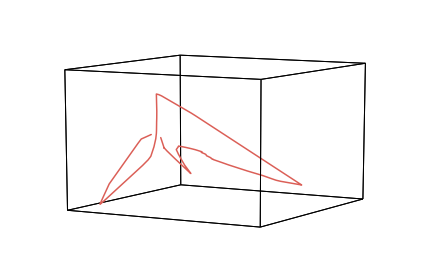

atlep1 in atlep2 space:


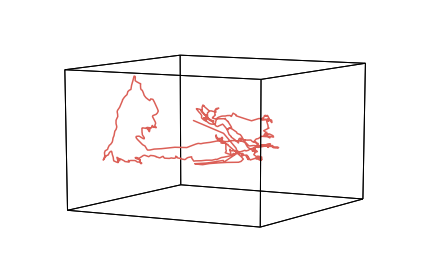

atlep1 in arrdev space:


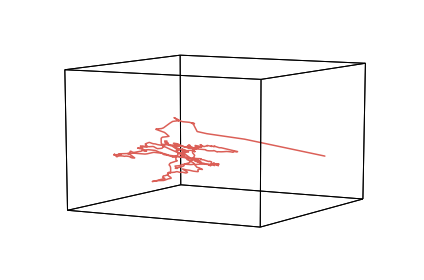

atlep1 in all space:


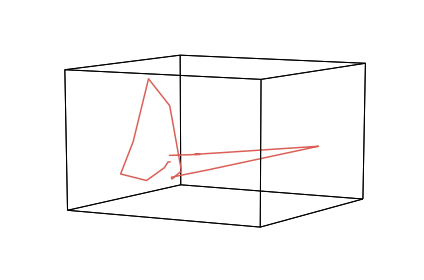

atlep1 in wikipedia space:


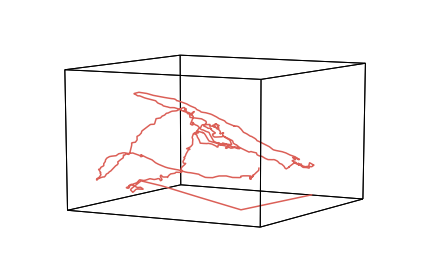

atlep2 in atlep1 space:


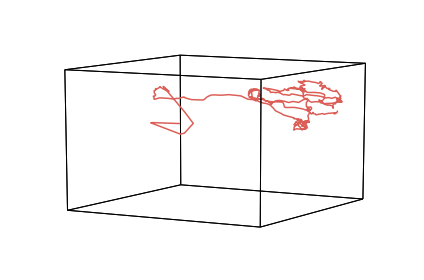

atlep2 in atlep2 space:


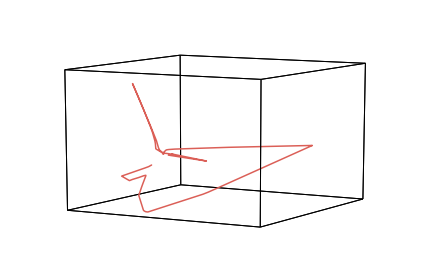

atlep2 in arrdev space:


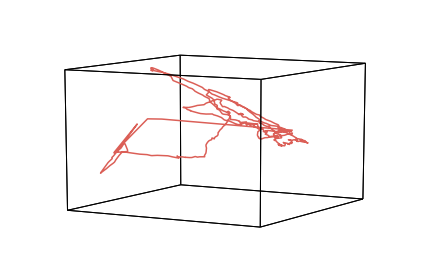

atlep2 in all space:


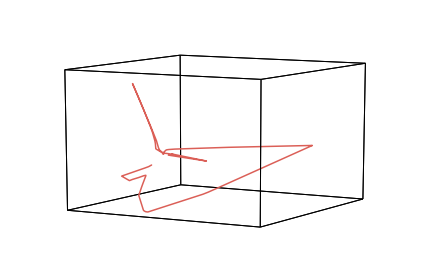

atlep2 in wikipedia space:


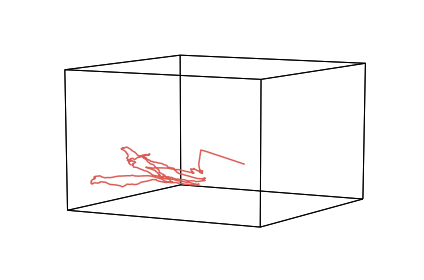

arrdev in atlep1 space:


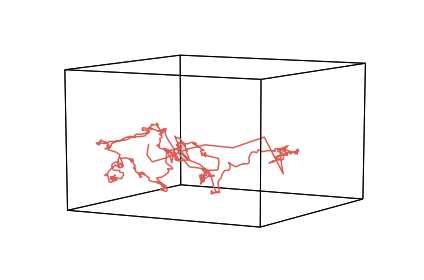

arrdev in atlep2 space:


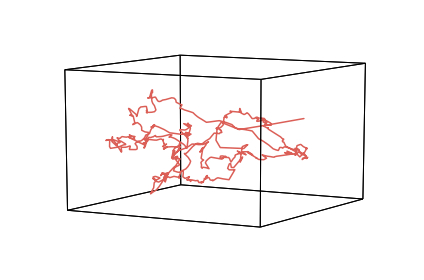

arrdev in arrdev space:


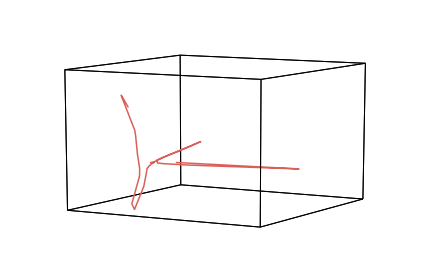

arrdev in all space:


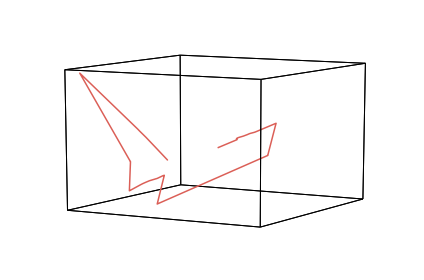

arrdev in wikipedia space:


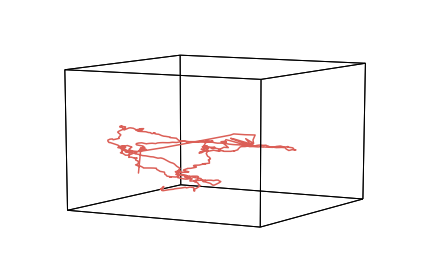

In [16]:
for col, data in ep_inspace.iteritems():
    for row, a in ep_inspace.iterrows():
        print(col + ' in ' + row + ' space:')
        hyp.plot(ep_inspace.loc[row,col])

## hyperalign episode models across spaces

In [19]:
ep_inspace_aligned = pd.DataFrame(columns=ep_inspace.columns, index=ep_inspace.index)

for col in ep_inspace_aligned.columns:
    ep_inspace_aligned[col] = hyp.align(ep_inspace[col].tolist())

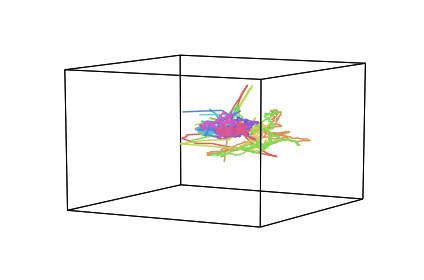

In [26]:
hyp.plot(ep_inspace_aligned.unstack().values.tolist(), animate=False, frame_rate=100, zoom=3)

No handles with labels found to put in legend.


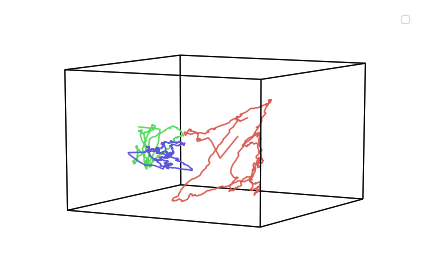

In [24]:
hyp.plot(ep_inspace_aligned.loc['wikipedia'].tolist(), animate=False, legend=['atlep1','atlep2','arrdev','all','wiki'],
         zoom=3, frame_rate=1000, chemtrails=False)

In [18]:
ep_inspace_aligned

,atlep1,atlep2,arrdev
atlep1,"[[0.0001957106792939526, 0.0001306772712837175...","[[0.0006831031652510952, -0.000653428327634559...","[[-9.106165524448627e-05, 2.5658068747143514e-..."
atlep2,"[[0.0011485125579399783, -0.000831930959333500...","[[0.008211929037003728, 0.007170714141128414, ...","[[0.0009527113319477734, -0.000113210426824131..."
arrdev,"[[-0.00502249250673988, -0.0007456086964409207...","[[0.0010645646065015947, -0.000937242443543427...","[[0.0037816340888932078, 0.0166477020830869, 0..."
all,"[[0.0015285446145226213, 0.0005338263138810512...","[[0.006472715075048585, 0.006814637789089609, ...","[[-0.0013646993119296386, 0.007952283209563591..."
wikipedia,"[[-0.002999954346589418, 0.0029191815076253067...","[[0.0019610813665706193, 0.0035189101684463143...","[[0.002112404693526169, 0.0067781396289993984,..."


In [63]:
for col in ep_inspace_aligned.columns:
    for row in ep_inspace_aligned.index:
        if col != row:
            print('\nMSD of ' + col + ' in ' + row + ' space:')
            msd = np.mean(cdist(ep_inspace_aligned.loc[row,col], ep_inspace_aligned.loc[col,col], 'sqeuclidean'))
            print('\t' + str(msd))


MSD of atlep1 in atlep2 space:
	0.08407231315385251

MSD of atlep1 in arrdev space:
	0.08305136774027373

MSD of atlep1 in all space:
	0.0994365082054829

MSD of atlep1 in wikipedia space:
	0.0877567218349209

MSD of atlep2 in atlep1 space:
	0.020517755748206568

MSD of atlep2 in arrdev space:
	0.022418359777333623

MSD of atlep2 in all space:
	0.02293409088814823

MSD of atlep2 in wikipedia space:
	0.022931041090365995

MSD of arrdev in atlep1 space:
	0.02146477831245863

MSD of arrdev in atlep2 space:
	0.021218225638945327

MSD of arrdev in all space:
	0.022483741295368776

MSD of arrdev in wikipedia space:
	0.021235430255796287
